# Measurement
1. Spectroscopy - goal: resonant freq 
2. separate 0/1, goal: dispersive shift
3. qubit spectroscopy - find qubit mode, power rabi & time rabi (calibrate pi gate) 
4. T1 & Ramsey (T2*) & spin echo(T2) & CPMG (T2)
automation ends
(input of automation: gates, hence need power & time)
5. find the precise qubit freq & pi gate
----- qubit cali ends-----

6. S/ T gates etc or two qubit gate


### Initialization

In [6]:
# LabOne Q:
from laboneq.simple import *

# Helpers:
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_simulation
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_results
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import time
import os
import laboneq
print(laboneq.__version__)

2.51.0


In [7]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""
descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12296
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/1/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="UCLA_SHFQC",  # setup name
)
# Are we emulating? or actually creating pulses?
emulate = False
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)

[2025.08.22 14:17:16.841] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is c:\Users\qubit\Desktop\Yi\Measurement\laboneq_output\log
[2025.08.22 14:17:16.843] INFO    VERSION: laboneq 2.51.0
[2025.08.22 14:17:16.846] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.22 14:17:16.853] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.08.22 14:17:16.858] WARNING SHFQC/QA:dev12296: Include the device options 'SHFQC/QC4CH' in the device setup ('options' field of the 'instruments' list in the device setup descriptor, 'device_options' argument when constructing instrument objects to be added to 'DeviceSetup' instances). This will become a strict requirement in the future.
[2025.08.22 14:17:16.864] INFO    Configuring the device setup
[2025.08.22 14:17:16.871] INFO    The device setup is configured


## Overall Resonator Spectroscopy

In [8]:
# frequency range of spectroscopy scan - around expected centre frequency as defined in qubit parameters
start_freq = 125e6 # actual_start_freq = central_freq - start_freq
stop_freq = 325.0e6
center_freq = 7e9
num_points = 3001 # stop - start / (num_points-1)
integration_time = 2e-5
num_averages = 9 # average number = 2^n, n_max = 17

measure_range = -30 # actual power = range (dBm) - 20log(amp)
measure_amp = 0.5
acquire_range = -35
acquire_amp = 1 #


In [9]:
# define sweep parameter
def create_readout_freq_sweep(qubit, start_freq, stop_freq, num_points):
    return LinearSweepParameter(
        uid=f"{qubit}_res_freq",
        start=start_freq,
        stop=stop_freq,
        count=num_points,
        axis_name="Frequency [Hz]",
    )

# function that defines a resonator spectroscopy experiment, and takes the frequency sweep as a parameter
def res_spectroscopy_cw(freq_sweep, exp_settings):
    # Create resonator spectroscopy experiment - uses only readout drive and signal acquisition
    exp_spec = Experiment(
        uid="Resonator Spectroscopy",
        signals=[
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    ## define experimental sequence
    # loop - average multiple measurements for each frequency - measurement in spectroscopy mode
    with exp_spec.acquire_loop_rt(
        uid="shots",
        count=pow(2, exp_settings["num_averages"]),
        acquisition_type=AcquisitionType.SPECTROSCOPY,
    ):
        with exp_spec.sweep(uid="res_freq", parameter=freq_sweep):
            # readout pulse and data acquisition
            with exp_spec.section(uid="spectroscopy"):
                # resonator signal readout
                exp_spec.acquire(
                    signal="acquire",
                    handle="res_spec",
                    length=exp_settings["integration_time"],
                )
            # relax time after readout - for signal processing and qubit relaxation to ground state
            with exp_spec.section(uid="relax", length=1e-6):
                exp_spec.reserve(signal="measure")
                exp_spec.reserve(signal="acquire")

    return exp_spec

In [10]:
# function that returns the calibration of the readout line oscillator for the experimental signals


def res_spec_calib(freq_sweep):

    exp_calibration = Calibration()
    exp_calibration["measure"] = SignalCalibration(
    oscillator = Oscillator(uid = "qa_osc_0", frequency = freq_sweep, modulation_type=ModulationType.HARDWARE),
    local_oscillator = Oscillator(uid="qa_lo", frequency = center_freq), range = measure_range, amplitude= measure_amp)
    
    exp_calibration["acquire"] = SignalCalibration(range = acquire_range, amplitude= acquire_amp)

    return exp_calibration


# signal maps for the two different qubits - maps the logical signal of the device setup to the experimental signals of the experiment


def res_spec_map(qubit):
    signal_map = {
        "measure": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "measure_line"
        ],
        "acquire": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "acquire_line"
        ],
    }
    return signal_map


# define the experiment with the frequency sweep relevant for qubit 0
freq_sweep = create_readout_freq_sweep("q0", start_freq, stop_freq, num_points)
exp_settings = {"integration_time": integration_time, "num_averages": num_averages}
exp_spec = res_spectroscopy_cw(freq_sweep, exp_settings)

# set signal calibration and signal map for experiment to qubit 0
exp_spec.set_calibration(res_spec_calib(freq_sweep))
exp_spec.set_signal_map(res_spec_map("q0"))

In [11]:
# compile the experiment on the open instrument session
compiled_res_spec = session.compile(exp_spec)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Resonator_Spectroscopy_Pulse_Sheet", compiled_res_spec)

[2025.08.22 14:17:16.922] INFO    Starting LabOne Q Compiler run...
[2025.08.22 14:17:17.588] INFO    Schedule completed. [0.663 s]
[2025.08.22 14:17:18.654] INFO    Code generation completed for all AWGs. [1.066 s]
[2025.08.22 14:17:18.654] INFO    Completed compilation step 1 of 1. [1.730 s]
[2025.08.22 14:17:18.662] INFO     ────────────────────────────────────────────────────────────────── 
[2025.08.22 14:17:18.662] INFO      Device         AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.08.22 14:17:18.662] INFO     ────────────────────────────────────────────────────────────────── 
[2025.08.22 14:17:18.662] INFO      device_shfqc     0         21            0           0         0  
[2025.08.22 14:17:18.662] INFO     ────────────────────────────────────────────────────────────────── 
[2025.08.22 14:17:18.662] INFO      TOTAL                      21            0                     0  
[2025.08.22 14:17:18.662] INFO     ────────────────────────────────────────────────────

c:\Users\qubit\Desktop\Yi\Measurement\Pulse_Sheets\Resonator_Spectroscopy_Pulse_Sheet_2025-08-22-14-17-18.html

In [12]:
# run the compiled experiemnt and extracted the data
result = session.run(compiled_res_spec)
amp = result.acquired_results["res_spec"].data
freqs = result.acquired_results["res_spec"].axis[0]

[2025.08.22 14:17:20.936] INFO    Starting near-time execution...
[2025.08.22 14:17:20.964] INFO    Estimated RT execution time: 32.40 s.
[2025.08.22 14:17:53.442] INFO    Finished near-time execution.


In [13]:
# Data Analysis
# --------- COMPUTE BASIC QUANTITIES ---------
freq_list = np.asarray(freqs, dtype=float).ravel() + float(center_freq)
amp = np.asarray(amp).ravel()

amplitude = np.abs(amp)
power_W = (amplitude**2) / 50.0
amp_dbm = 10.0 * np.log10(power_W / 1e-3)

# --------- SORT BY FREQUENCY (important for unwrap/fits) ---------
order = np.argsort(freq_list)
freq_list = freq_list[order]
amp = amp[order]
amp_dbm = amp_dbm[order]

# --------- PHASE (robust) + LINEAR DETREND ---------
phase_rad = np.unwrap(np.arctan2(amp.imag, amp.real))
f_ghz = freq_list / 1e9
f0 = f_ghz - f_ghz.mean()  # center to improve conditioning
slope_c, intercept = np.polyfit(f0, phase_rad, 1)
linear_fit = slope_c * f0 + intercept
phase_rad_detrended = phase_rad - linear_fit

# --------- FIND 6 LOWEST DIPS (local minima) ---------
def find_candidate_minima(y):
    """Return indices of local minima (y[i] <= neighbors)."""
    return np.where((y[1:-1] <= y[:-2]) & (y[1:-1] <= y[2:]))[0] + 1

# Prefer SciPy if available (robust); fallback otherwise
try:
    from scipy.signal import find_peaks
    inv = -amp_dbm
    peaks, _ = find_peaks(inv, prominence=0.2, distance=max(1, len(inv)//200))
    cand_idx = peaks if len(peaks) else find_candidate_minima(amp_dbm)
except Exception:
    cand_idx = find_candidate_minima(amp_dbm)

if len(cand_idx) == 0:
    cand_idx = np.array([int(np.argmin(amp_dbm))])

# pick the 6 deepest among candidates
take = min(6, len(cand_idx))
deep_order = np.argsort(amp_dbm[cand_idx])[:take]
dips_idx = cand_idx[deep_order]

# --------- PARABOLIC REFINEMENT (3-point quadratic) ---------
dips_freq = []
dips_amp = []
for i in dips_idx:
    f_est = freq_list[i]
    a_est = amp_dbm[i]
    if 0 < i < len(freq_list) - 1:
        x = freq_list[i-1:i+2]
        y = amp_dbm[i-1:i+2]
        qa, qb, qc = np.polyfit(x, y, 2)
        if qa > 0:
            f_v = -qb / (2 * qa)
            if x[0] <= f_v <= x[2]:
                f_est = f_v
                a_est = qa * f_est**2 + qb * f_est + qc
    dips_freq.append(f_est)
    dips_amp.append(a_est)

dips_freq = np.array(dips_freq)
dips_amp = np.array(dips_amp)

# sort dips by frequency for nicer labeling
srt = np.argsort(dips_freq)
dips_freq = dips_freq[srt]
dips_amp = dips_amp[srt]

# --------- SAVE RESULTS ---------
outdir = "resonator_results"
os.makedirs(outdir, exist_ok=True)

# amplitude CSV (keep Hz for precision)
np.savetxt(
    os.path.join(outdir, "amplitude_results.csv"),
    np.column_stack([freq_list, amp_dbm]),
    delimiter=",",
    header="freq_Hz, amplitude_dBm",
)

# phase CSV (keep Hz for precision)
np.savetxt(
    os.path.join(outdir, "phase_results.csv"),
    np.column_stack([freq_list, phase_rad_detrended, phase_rad]),
    delimiter=",",
    header="freq_Hz, phase_rad_detrended, phase_rad",
)


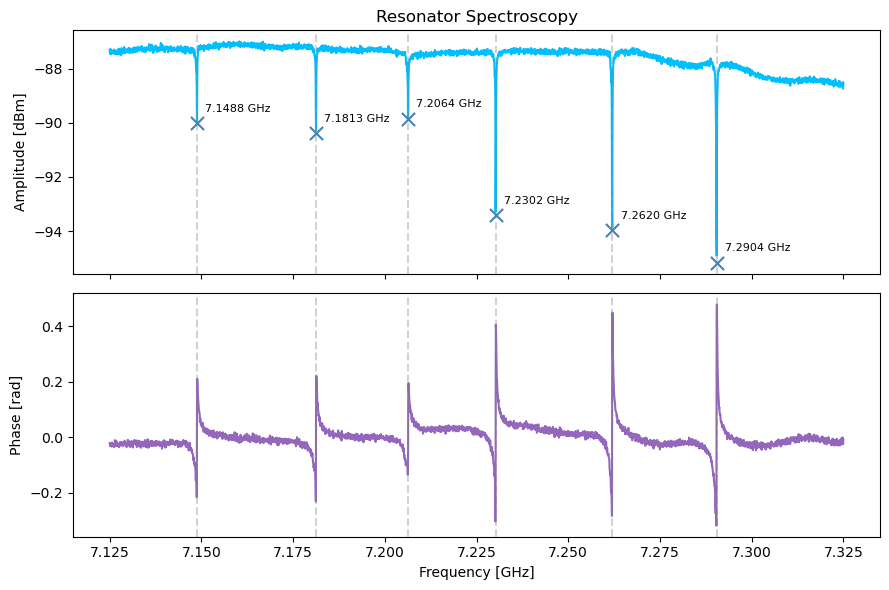

In [14]:
# --------- PLOT: amplitude + phase with 6 dips (X in GHz) ---------
freq_list_GHz = freq_list / 1e9
dips_freq_GHz = dips_freq / 1e9

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# amplitude
ax1.plot(freq_list_GHz, amp_dbm, linestyle="-", color="deepskyblue")
ax1.set_ylabel("Amplitude [dBm]")
ax1.set_title("Resonator Spectroscopy")

# mark dips + vertical lines + labels (all in GHz)
for f_min_GHz, a_min in zip(dips_freq_GHz, dips_amp):
    ax1.scatter([f_min_GHz], [a_min], marker="x", s=90, color="steelblue", zorder=5)
    ax1.axvline(f_min_GHz, linestyle="--", alpha=0.35, color="gray")
    ax1.annotate(
        f"{f_min_GHz:.4f} GHz",
        xy=(f_min_GHz, a_min),
        xytext=(6, 8),
        textcoords="offset points",
        fontsize=8,
    )

# phase (detrended)
ax2.plot(freq_list_GHz, phase_rad_detrended, linestyle="-", color="tab:purple")
for f_min_GHz in dips_freq_GHz:
    ax2.axvline(f_min_GHz, linestyle="--", alpha=0.35, color="gray")
ax2.set_xlabel("Frequency [GHz]")
ax2.set_ylabel("Phase [rad]")

plt.tight_layout()
plt.savefig(os.path.join(outdir, "resonator_spec_GHz.png"), dpi=300)
plt.show()
